In [1]:
import ggcmpy
from ggcmpy import plot_polar
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
import pathlib
import xarray as xr

In [2]:
GGCM_DIR = pathlib.Path("/mnt/home/germaschewski/cu1010/runs/260528_2010/target")

phi0 = 0.13037126e10
sig0 = 0.11889699

In [3]:
i2s = xr.open_dataset(GGCM_DIR / "backups/iono_to_sigmas.bp")

i2s["prec_e_fe"] = i2s["prec_e_fe_1"] + i2s["prec_e_fe_2"]
i2s["prec_e_e0"] = (
    i2s["prec_e_e0_1"] * i2s["prec_e_fe_1"] + i2s["prec_e_e0_2"] * i2s["prec_e_fe_2"]
) / i2s["prec_e_fe"]

s2i_ctim = xr.open_dataset(GGCM_DIR / "backups/sigmas_to_iono.bp")
s2i_sigaa2 = xr.open_dataset(GGCM_DIR / "sigmas_to_iono.bp")

s2i_ctim["time"] = i2s["time"]
s2i_sigaa2["time"] = i2s["time"]

to_gitm_ctim = xr.open_dataset(GGCM_DIR / "backups/to_gitm.bp")
to_gitm_sigaa2 = xr.open_dataset(GGCM_DIR / "to_gitm.bp")

# i2s relevant variables:
# fac
# fac_dyn
# pot
# rrio
# sigh
# sigp
# prec_e_fe
# prec_e_e0

# s2i variables:
# fac_dyn
# sigh
# sigp

# to_gitm variables:
# Electron Energy Flux (ergs/cm2)
# Electron Mean Energy (eV)
# Potential (V)

In [4]:
# Convert to_gitm's 2D time array to a 1D datetime coordinate.
# 1. Extract the 2D time array.
time_values = to_gitm_ctim["time"].values

# 2. Convert to a Pandas DataFrame.
df_time = pd.DataFrame(
    time_values[:, :7],
    columns=[
        "year",
        "month",
        "day",
        "hour",
        "minute",
        "second",
        "millisecond",
    ],
)

# 3. Create the base datetime objects.
datetimes = pd.to_datetime(df_time)

# 4. Create a new variable using to_gitm with the new 1D datetimes.
to_gitm_ctim_fixed = to_gitm_ctim.drop_vars("time").assign_coords(time=datetimes)
to_gitm_sigaa2_fixed = to_gitm_sigaa2.drop_vars("time").assign_coords(time=datetimes)

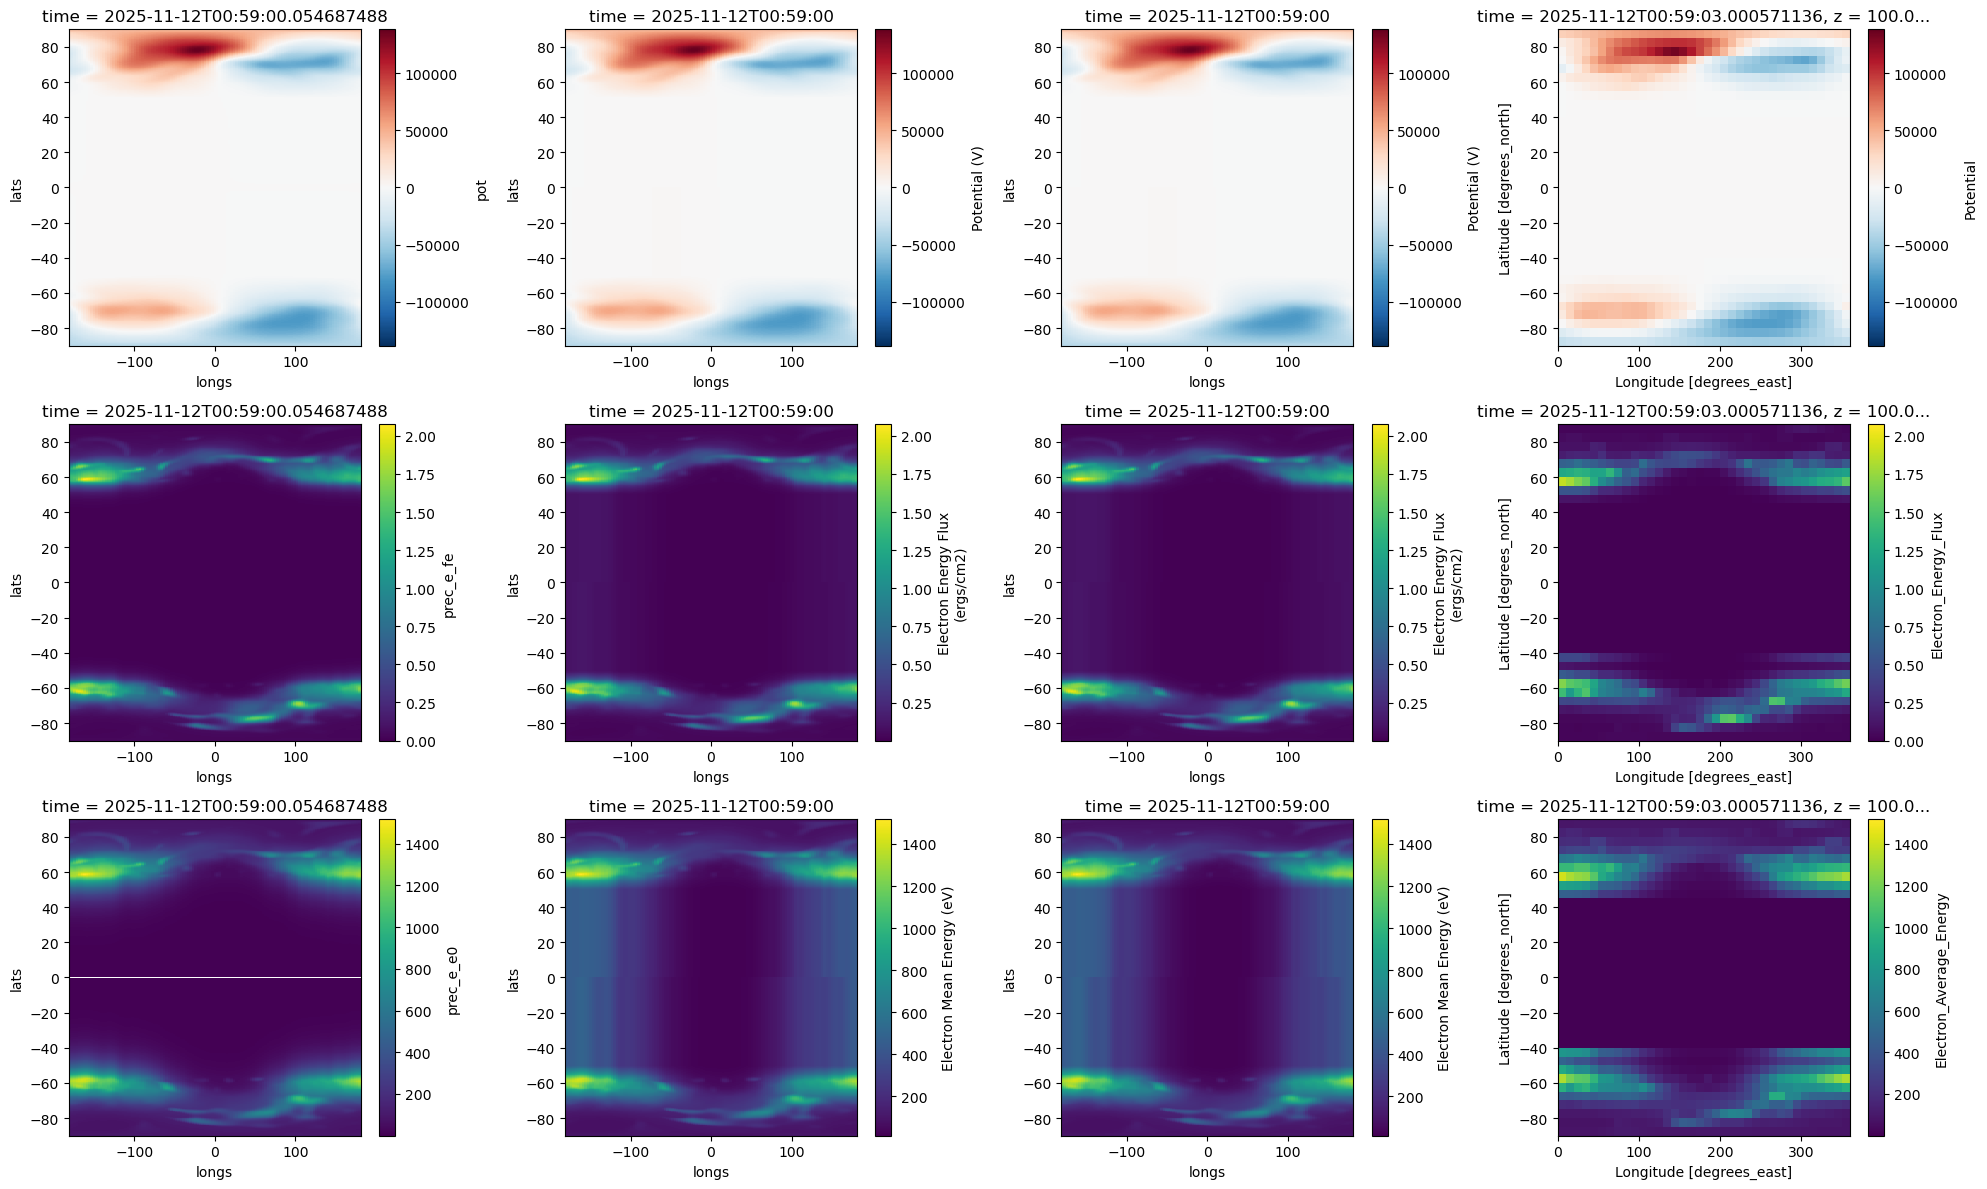

In [5]:
fig, axs = plt.subplots(3, 4, figsize=(20, 12))
# signorm = colors.LogNorm(vmin=1.0, vmax=20.0)

gel = xr.open_dataset(
    "/mnt/home/germaschewski/cu1010/repos/GITM.adios2/run6/UA/data/2DGEL_t251112_005903.nc"
)
_i2s = i2s.sel(time=gel.time, method="nearest")
_to_gitm_ctim = to_gitm_ctim_fixed.sel(time=gel.time, method="nearest")
_to_gitm_sigaa2 = to_gitm_sigaa2_fixed.sel(time=gel.time, method="nearest")

(_i2s["pot"] * phi0).plot(ax=axs[0, 0], ylim=(-90, 90), vmax=_i2s["pot"].max() * phi0)
(_i2s["prec_e_fe"] * 1e3).plot(
    ax=axs[1, 0], ylim=(-90, 90), vmax=_i2s["prec_e_fe"].max() * 1e3
)
_i2s["prec_e_e0"].plot(ax=axs[2, 0], ylim=(-90, 90), vmax=_i2s["prec_e_e0"].max())
_to_gitm_ctim["Potential (V)"].plot(
    ax=axs[0, 1], ylim=(-90, 90), vmax=_i2s["pot"].max() * phi0
)
_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 1], ylim=(-90, 90), vmax=_i2s["prec_e_fe"].max() * 1e3
)
_to_gitm_ctim["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 1], ylim=(-90, 90), vmax=_i2s["prec_e_e0"].max()
)
_to_gitm_sigaa2["Potential (V)"].plot(
    ax=axs[0, 2], ylim=(-90, 90), vmax=_i2s["pot"].max() * phi0
)
_to_gitm_sigaa2["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 2], ylim=(-90, 90), vmax=_i2s["prec_e_fe"].max() * 1e3
)
_to_gitm_sigaa2["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 2], ylim=(-90, 90), vmax=_i2s["prec_e_e0"].max()
)
gel["pot"].T.plot(ax=axs[0, 3], ylim=(-90, 90), vmax=_i2s["pot"].max() * phi0)
gel["Electron_Energy_Flux"].T.plot(
    ax=axs[1, 3], ylim=(-90, 90), vmax=_i2s["prec_e_fe"].max() * 1e3
)
gel["Electron_Average_Energy"].T.plot(
    ax=axs[2, 3], ylim=(-90, 90), vmax=_i2s["prec_e_e0"].max()
)
plt.tight_layout()

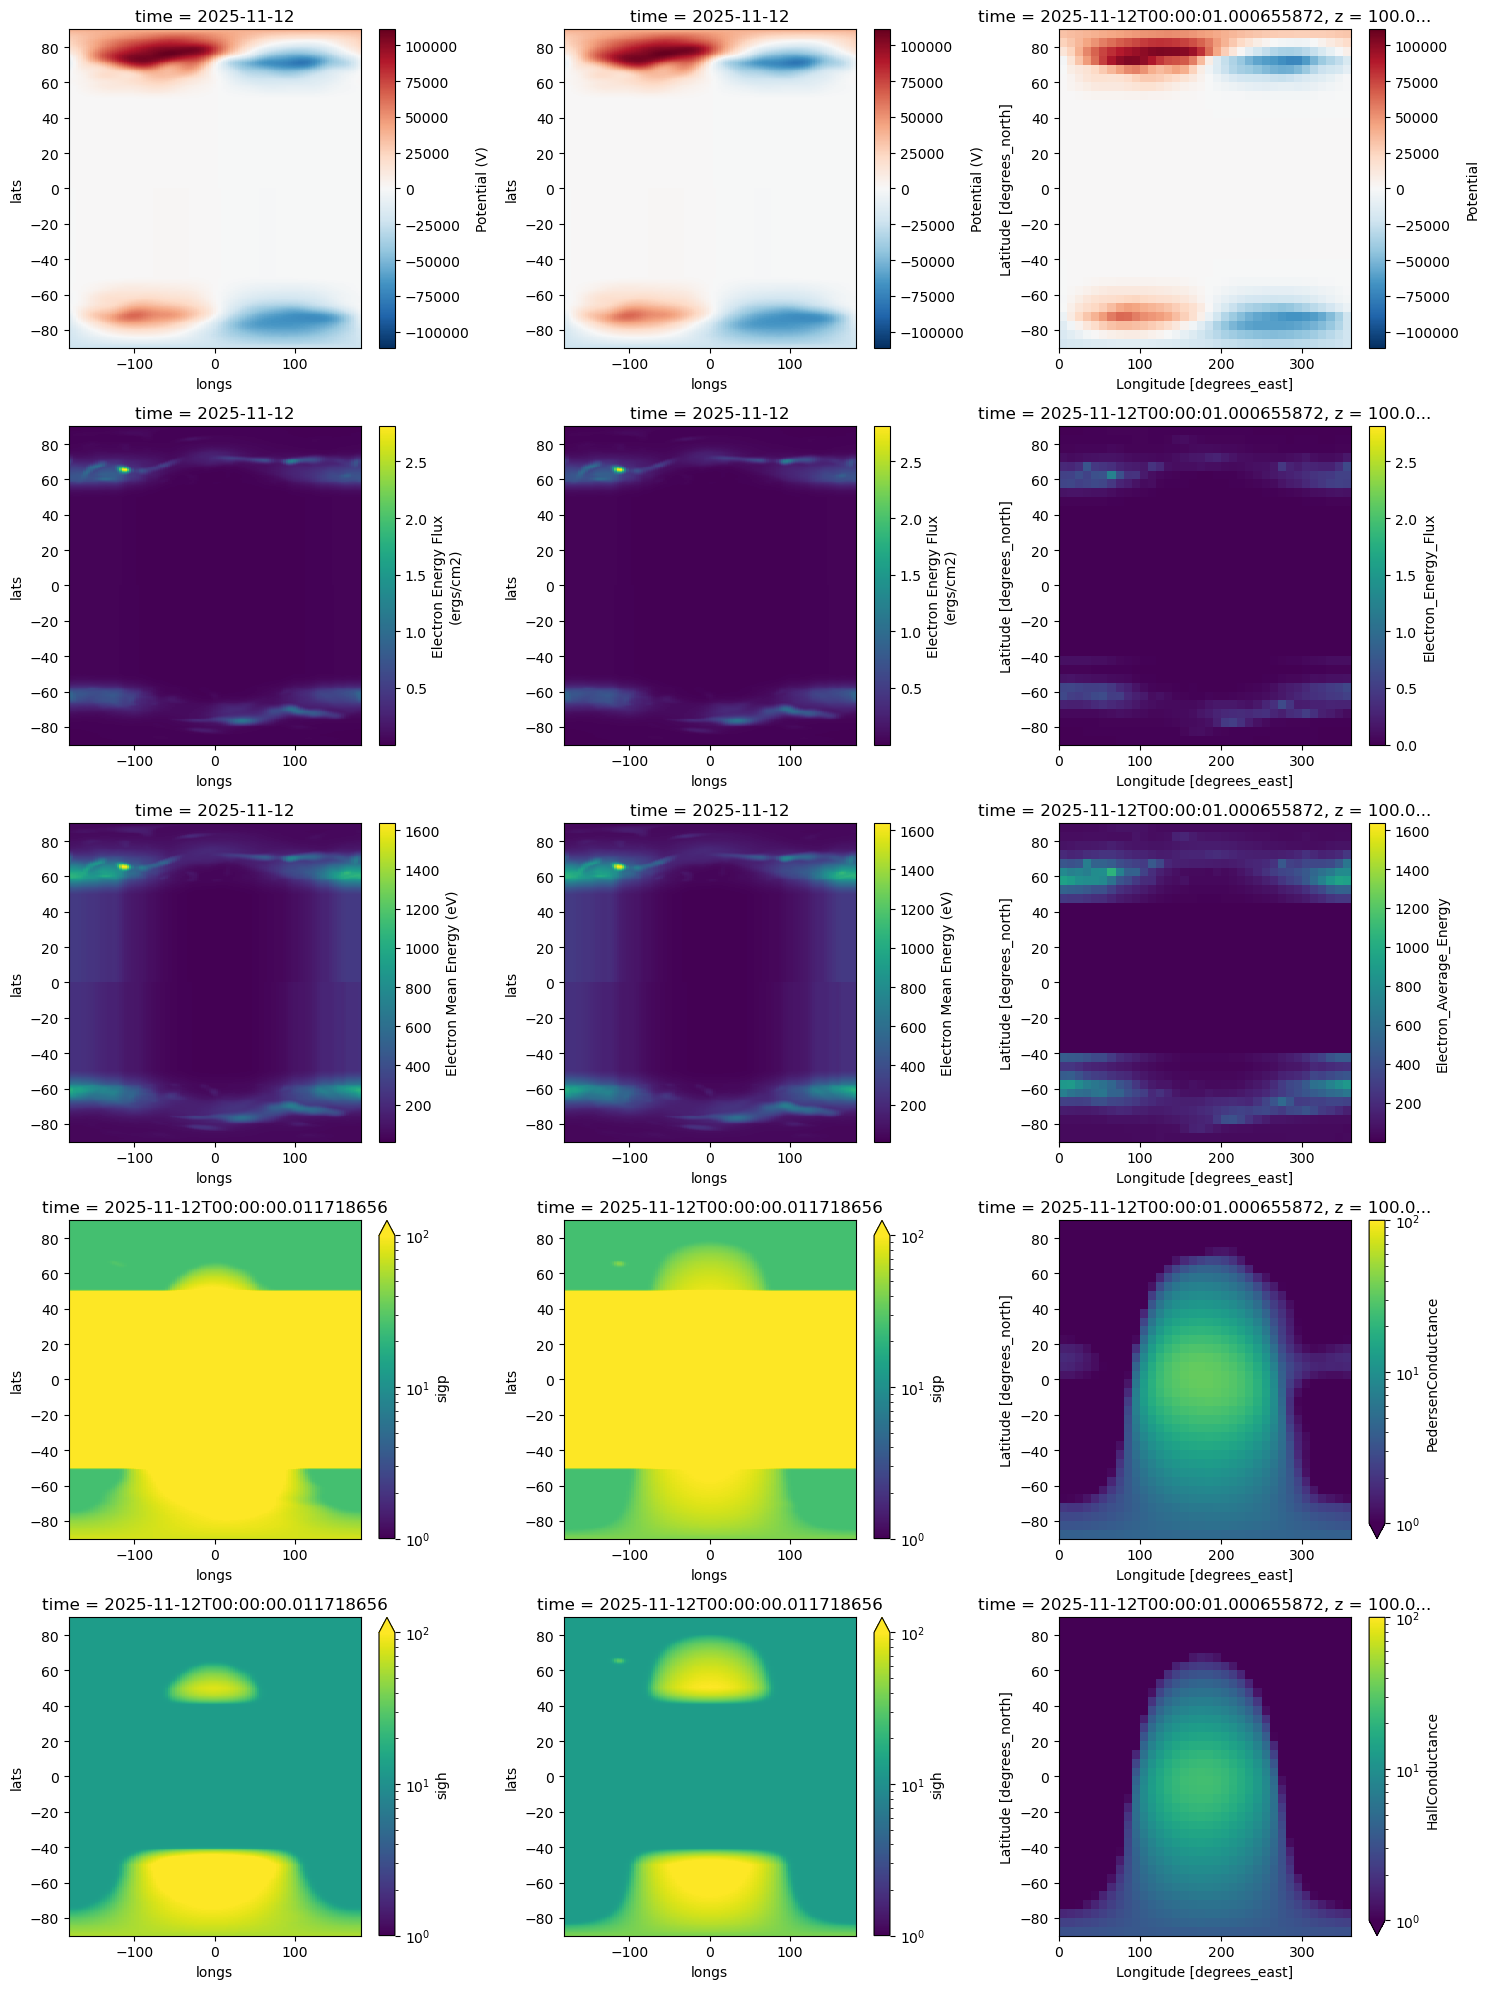

In [6]:
fig, axs = plt.subplots(5, 3, figsize=(15, 20))
sigmax = 100.0

gel = xr.open_dataset(
    "/mnt/home/germaschewski/cu1010/repos/GITM.adios2/run6/UA/data/2DGEL_t251112_000001.nc"
)
_s2i_ctim = s2i_ctim.sel(time=gel.time, method="nearest")
_s2i_sigaa2 = s2i_sigaa2.sel(time=gel.time, method="nearest")
_to_gitm_ctim = to_gitm_ctim_fixed.sel(time=gel.time, method="nearest")
_to_gitm_sigaa2 = to_gitm_sigaa2_fixed.sel(time=gel.time, method="nearest")

_to_gitm_ctim["Potential (V)"].plot(
    ax=axs[0, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 0],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_ctim["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_ctim["sigp"].plot(
    ax=axs[3, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_ctim["sigh"].plot(
    ax=axs[4, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_to_gitm_sigaa2["Potential (V)"].plot(
    ax=axs[0, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_sigaa2["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 1],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_sigaa2["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_sigaa2["sigp"].plot(
    ax=axs[3, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_sigaa2["sigh"].plot(
    ax=axs[4, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["pot"].T.plot(ax=axs[0, 2], vmax=_to_gitm_ctim["Potential (V)"].max())
gel["Electron_Energy_Flux"].T.plot(
    ax=axs[1, 2],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
gel["Electron_Average_Energy"].T.plot(
    ax=axs[2, 2], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
gel["PedCond"].T.plot(
    ax=axs[3][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["HalCond"].T.plot(
    ax=axs[4][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
plt.tight_layout()

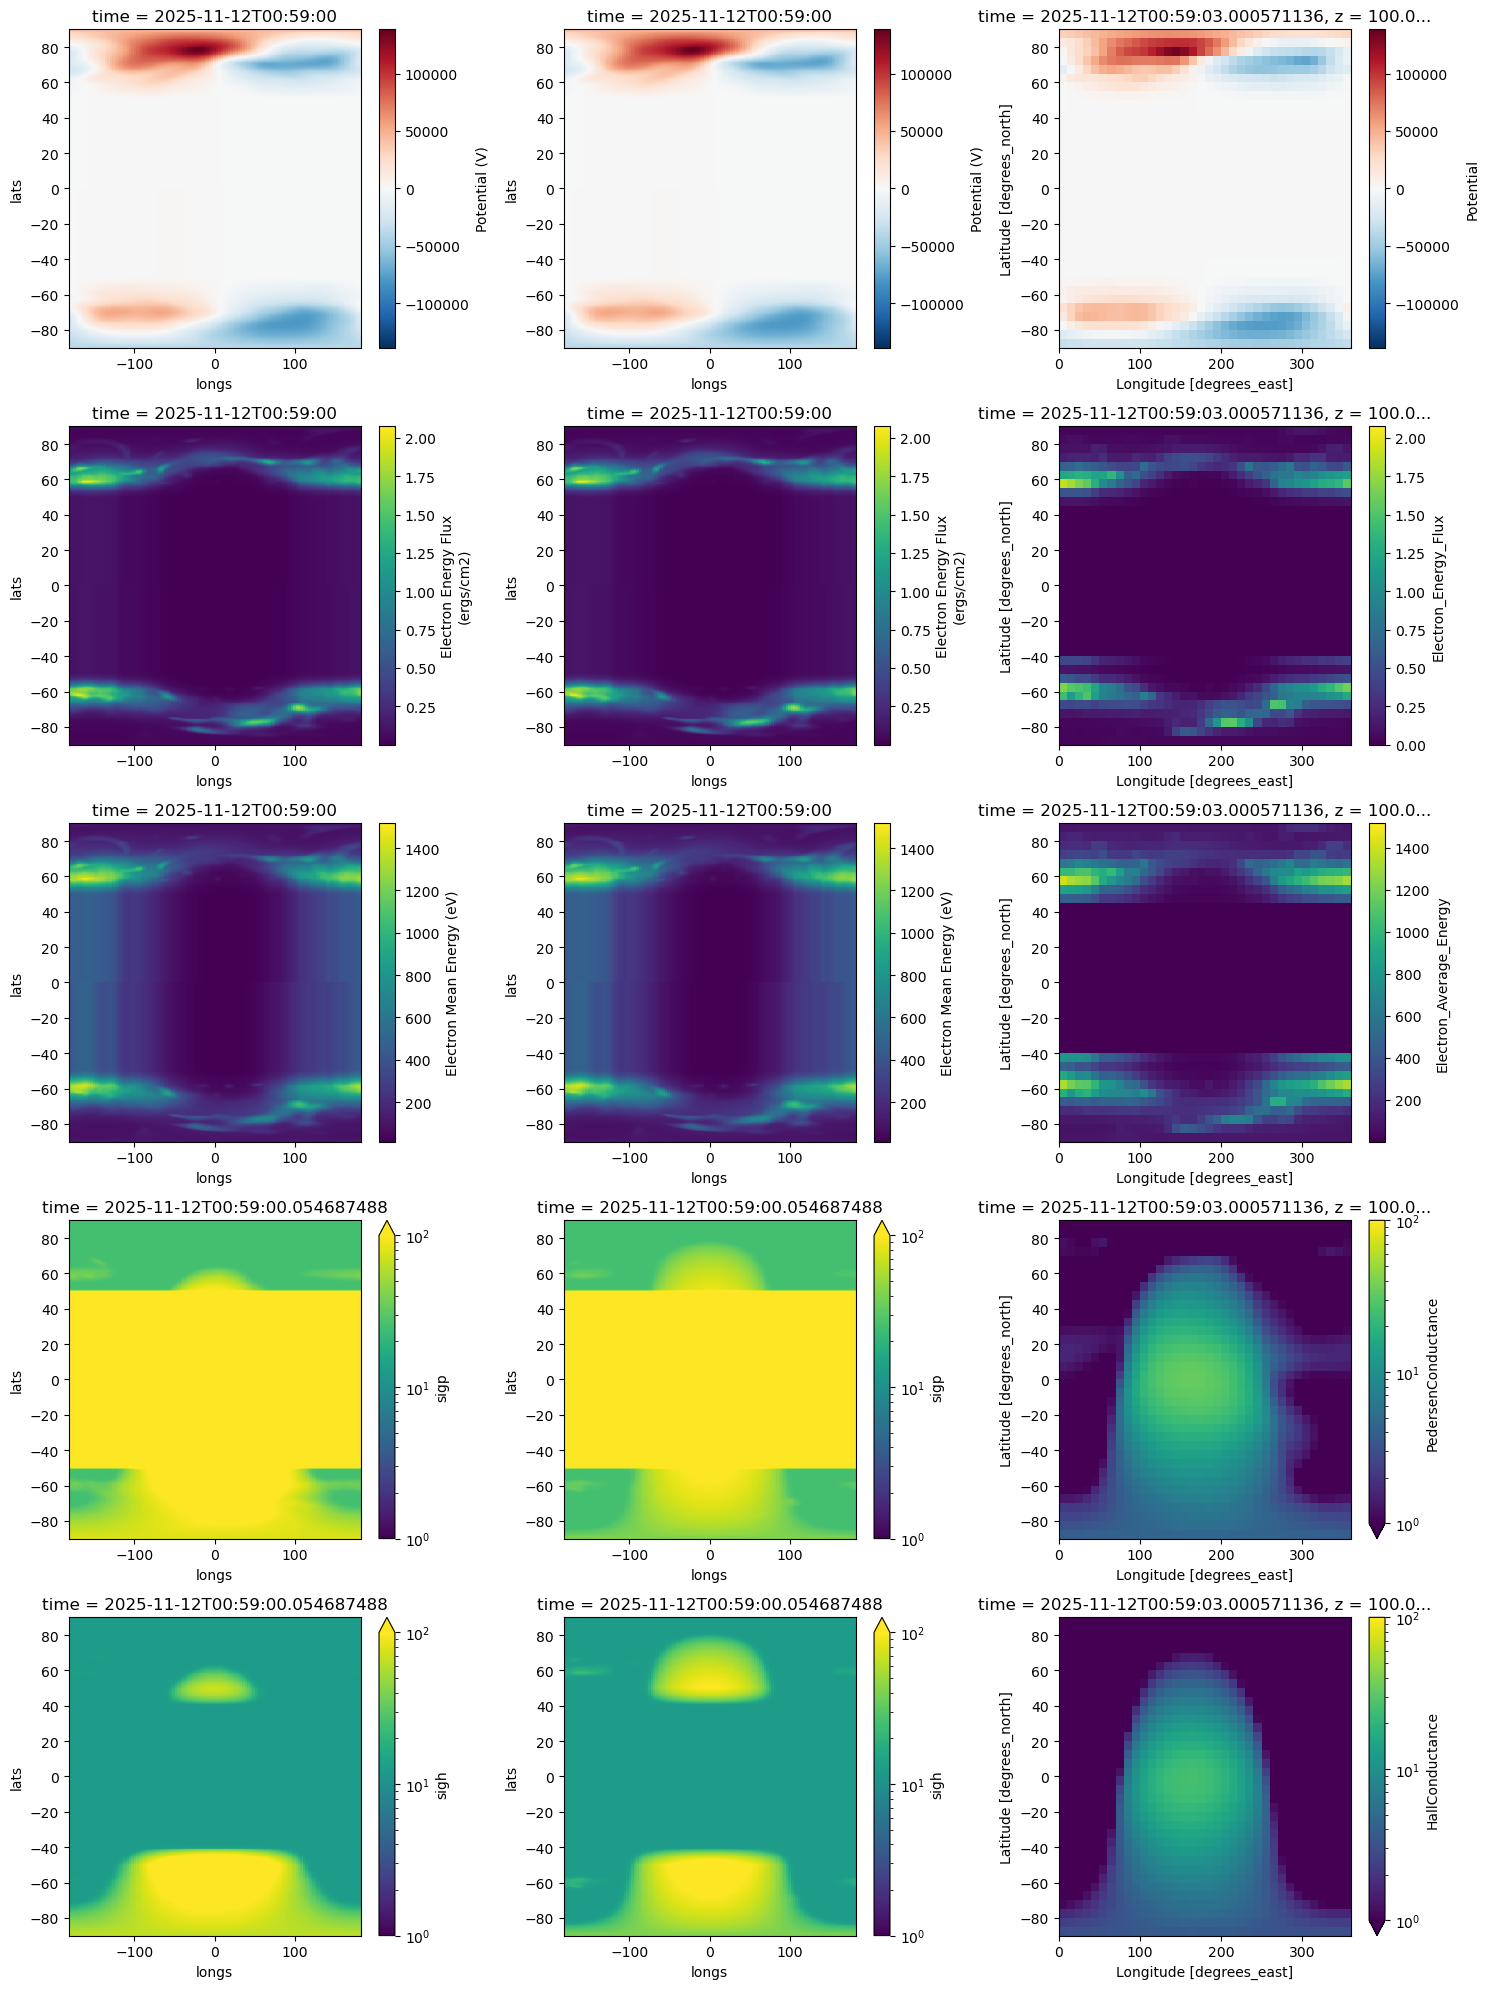

In [7]:
fig, axs = plt.subplots(5, 3, figsize=(15, 20))
sigmax = 100.0

gel = xr.open_dataset(
    "/mnt/home/germaschewski/cu1010/repos/GITM.adios2/run6/UA/data/2DGEL_t251112_005903.nc"
)
_s2i_ctim = s2i_ctim.sel(time=gel.time, method="nearest")
_s2i_sigaa2 = s2i_sigaa2.sel(time=gel.time, method="nearest")
_to_gitm_ctim = to_gitm_ctim_fixed.sel(time=gel.time, method="nearest")
_to_gitm_sigaa2 = to_gitm_sigaa2_fixed.sel(time=gel.time, method="nearest")

_to_gitm_ctim["Potential (V)"].plot(
    ax=axs[0, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 0],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_ctim["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_ctim["sigp"].plot(
    ax=axs[3, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_ctim["sigh"].plot(
    ax=axs[4, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_to_gitm_sigaa2["Potential (V)"].plot(
    ax=axs[0, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_sigaa2["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 1],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_sigaa2["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_sigaa2["sigp"].plot(
    ax=axs[3, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_sigaa2["sigh"].plot(
    ax=axs[4, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["pot"].T.plot(ax=axs[0, 2], vmax=_to_gitm_ctim["Potential (V)"].max())
gel["Electron_Energy_Flux"].T.plot(
    ax=axs[1, 2],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
gel["Electron_Average_Energy"].T.plot(
    ax=axs[2, 2], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
gel["PedCond"].T.plot(
    ax=axs[3][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["HalCond"].T.plot(
    ax=axs[4][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
plt.tight_layout()

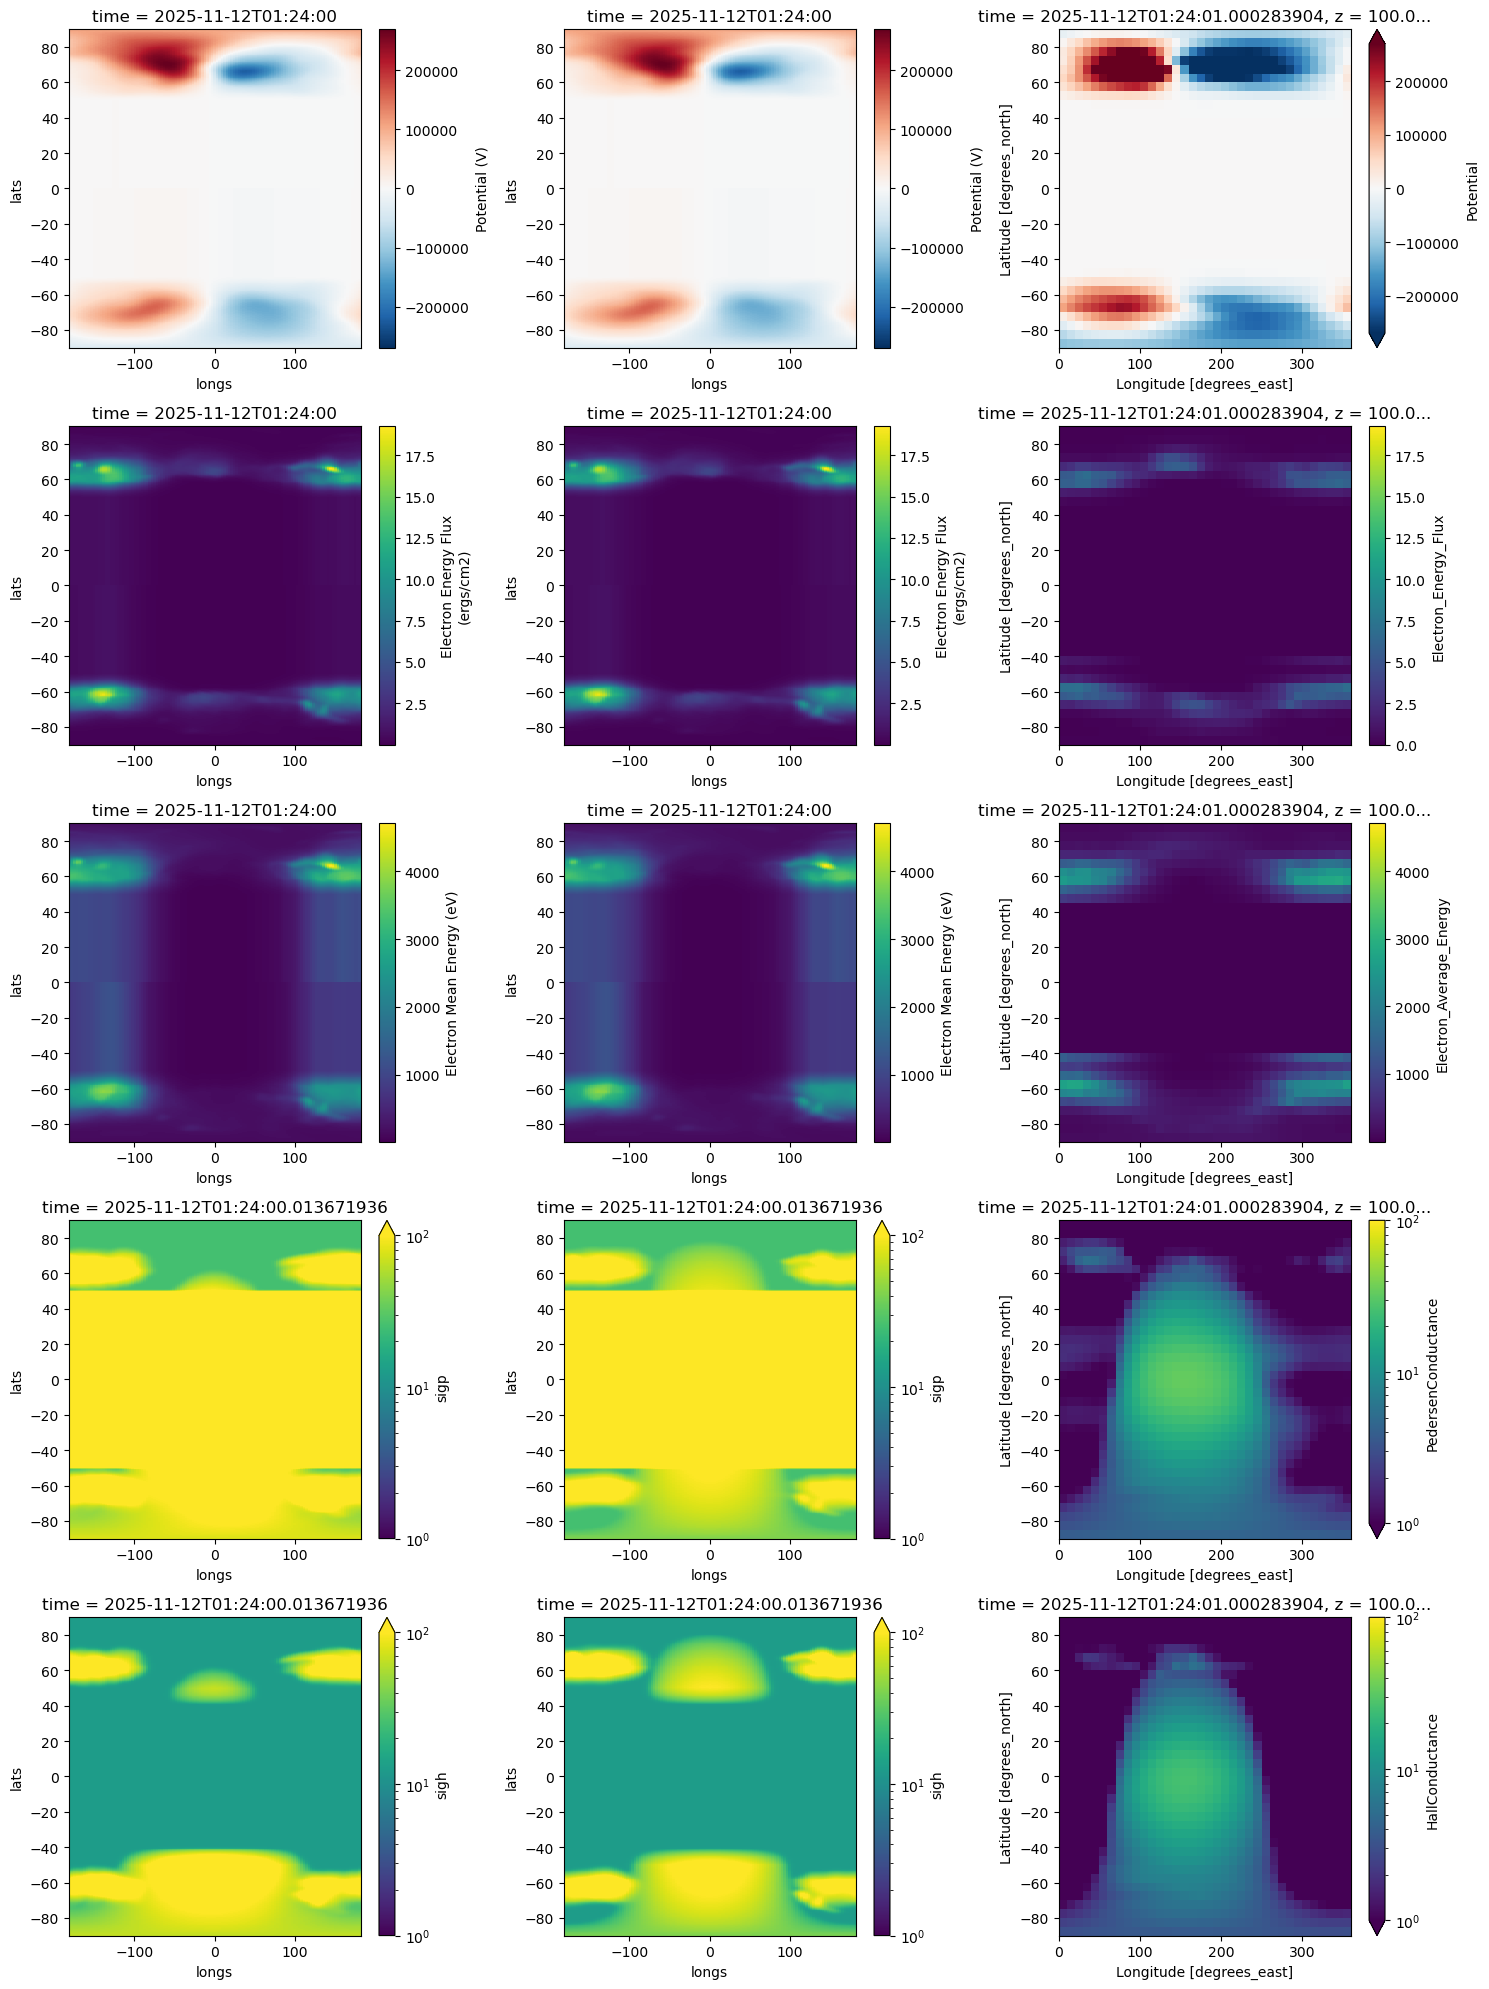

In [8]:
fig, axs = plt.subplots(5, 3, figsize=(15, 20))
sigmax = 100.0

gel = xr.open_dataset(
    "/mnt/home/germaschewski/cu1010/repos/GITM.adios2/run6/UA/data/2DGEL_t251112_012401.nc"
)
_s2i_ctim = s2i_ctim.sel(time=gel.time, method="nearest")
_s2i_sigaa2 = s2i_sigaa2.sel(time=gel.time, method="nearest")
_to_gitm_ctim = to_gitm_ctim_fixed.sel(time=gel.time, method="nearest")
_to_gitm_sigaa2 = to_gitm_sigaa2_fixed.sel(time=gel.time, method="nearest")

_to_gitm_ctim["Potential (V)"].plot(
    ax=axs[0, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 0],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_ctim["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 0], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_ctim["sigp"].plot(
    ax=axs[3, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_ctim["sigh"].plot(
    ax=axs[4, 0], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_to_gitm_sigaa2["Potential (V)"].plot(
    ax=axs[0, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Potential (V)"].max()
)
_to_gitm_sigaa2["Electron Energy Flux (ergs/cm2)"].plot(
    ax=axs[1, 1],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
_to_gitm_sigaa2["Electron Mean Energy (eV)"].plot(
    ax=axs[2, 1], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
_s2i_sigaa2["sigp"].plot(
    ax=axs[3, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
_s2i_sigaa2["sigh"].plot(
    ax=axs[4, 1], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["pot"].T.plot(ax=axs[0, 2], vmax=_to_gitm_ctim["Potential (V)"].max())
gel["Electron_Energy_Flux"].T.plot(
    ax=axs[1, 2],
    ylim=(-90, 90),
    vmax=_to_gitm_ctim["Electron Energy Flux (ergs/cm2)"].max(),
)
gel["Electron_Average_Energy"].T.plot(
    ax=axs[2, 2], ylim=(-90, 90), vmax=_to_gitm_ctim["Electron Mean Energy (eV)"].max()
)
gel["PedCond"].T.plot(
    ax=axs[3][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
gel["HalCond"].T.plot(
    ax=axs[4][2], ylim=(-90, 90), norm=colors.LogNorm(vmin=1, vmax=sigmax)
)
plt.tight_layout()

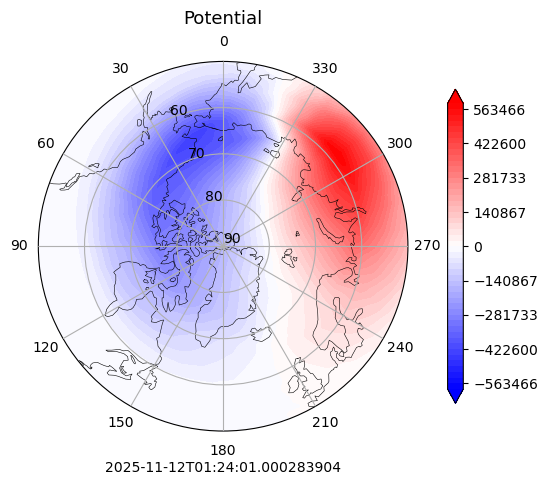

In [9]:
gel["pot"].ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=False,
)

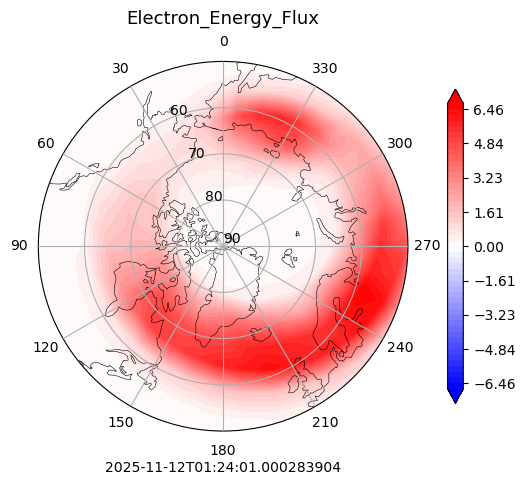

In [10]:
gel["Electron_Energy_Flux"].ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=False,
)

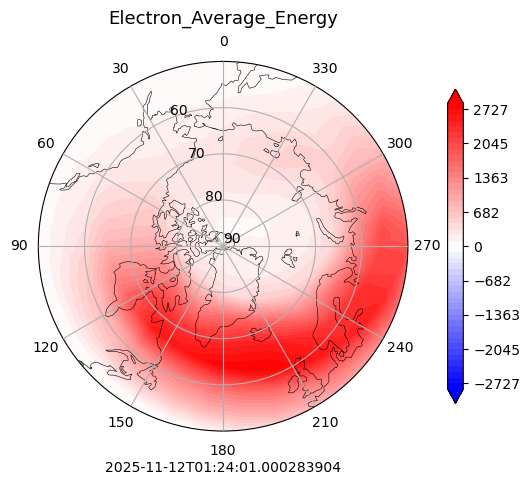

In [11]:
gel["Electron_Average_Energy"].ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=False,
)

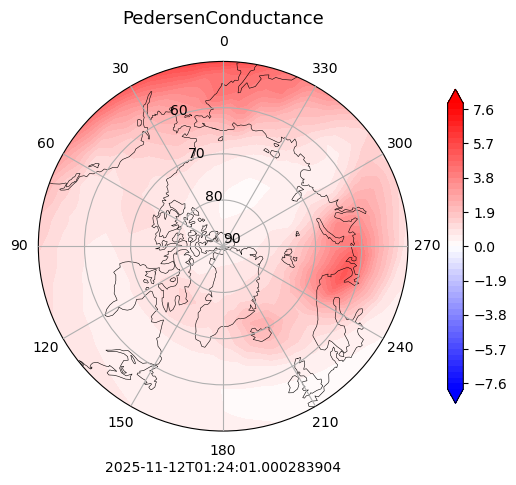

In [12]:
gel["PedCond"].ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=False,
)

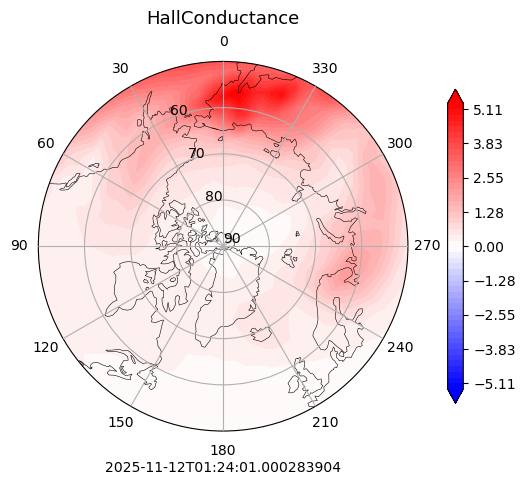

In [13]:
gel["HalCond"].ggcm.plot(
    coastlines=True,
    # stations=True,
    # highlight_station=current_station,
    # levels=levels,
    timestamp=True,
    mlt=False,
)